In [1]:
from firedrake import *

In [2]:
import matplotlib.pyplot as plt
from typing import Any

In [17]:
mesh1 = RectangleMesh(50, 50, 2, 1)

x, y = SpatialCoordinate(mesh1)
T = FunctionSpace(mesh1, "HDiv Trace", 0)
center = firedrake.Function(T).interpolate(sqrt((x - 0.5) ** 2 + (y - 0.5) ** 2) < 0.1)

ind = 555
mesh = RelabeledMesh(mesh1, [center], [ind])

# Also works with degree=0.
degree = 1
Q = VectorFunctionSpace(mesh, "CG", degree+1, dim=2)
V = FunctionSpace(mesh, "CG", degree)

Z = MixedFunctionSpace([V,Q])
z = Function(Z)
u,psi = split(z)

u_old = Function(V) 
psi_old = Function(Q)

z_trial = TestFunction(Z)
v,w = split(z_trial)

alpha = Constant(1)

# See (5.5a) and (5.5b) in https://doi.org/10.1016/j.cma.2025.118181.
F = inner(psi / sqrt(1+dot(psi,psi)), w)*dx(degree=6) + inner(u, div(w))*dx
F += inner(div(psi), v)*dx - inner(div(psi_old), v)*dx + alpha*inner(Constant(1), v)*dx

bcs =  [DirichletBC(Z.sub(0), 0, ind)]  # , DirichletBC(Z.sub(1), 0, ind)]

# Use LU factorization
tol = 1e-4
sp = {
    "snes_monitor": None,
    "snes_linesearch_type": "l2",
    "snes_linesearch_damping": 0.5,
    "snes_rtol": tol,
    "snes_atol": tol,
    "snes_stol": tol,
    "snes_max_it": 100,
    "pc_factor_mat_solver_type": "mumps",
    "mat_mumps_icntl_14": 500,
    "snes_error_if_not_converged": True,
    "ksp_type": "preonly",
    "pc_type": "lu",
}

NLVP = NonlinearVariationalProblem(F, z, bcs=bcs)
NLVS = NonlinearVariationalSolver(NLVP, solver_parameters=sp)

u, psi = z.subfunctions
out = VTKFile("out/eikonal.pvd")
alpha.assign(1)
u.assign(1)

lvpp_max_its = 40 # max LVPP iterates
for k in range(lvpp_max_its):
    print(f"alpha = {float(alpha)}")
    u_old.assign(u)

    NLVS.solve() # solve the LVPP subproblem
    psi_old.assign(psi) # update the previous latent variable

    out.write(u) # save current iterate to disk
    
    # break if ||u^k - u^{k-1}||_{L^2} <= 1e-4
    nrm = norm(u-u_old, "L2")
    print("LVPP it: %s, Cauchy Error: %s\n"%(k,nrm))
    if nrm < 1e-4:
        break

    # update rule for proximal parameter alpha
    if float(alpha) < 10:
        alpha.assign(sqrt(2) * alpha)

alpha = 1.0
  0 SNES Function norm 3.458006105001e-01
  1 SNES Function norm 2.095412666013e-04
  2 SNES Function norm 7.444531187874e-07
LVPP it: 0, Cauchy Error: 1.3593265011057025

alpha = 1.4142135623730951
  0 SNES Function norm 5.538262864933e-02
  1 SNES Function norm 1.057564147723e-03
  2 SNES Function norm 8.996431636103e-06
LVPP it: 1, Cauchy Error: 0.07423279362346111

alpha = 2.0000000000000004
  0 SNES Function norm 7.832286506536e-02
  1 SNES Function norm 1.499391942248e-03
  2 SNES Function norm 1.104186876654e-05
LVPP it: 2, Cauchy Error: 0.060056794120790645

alpha = 2.8284271247461907
  0 SNES Function norm 1.107652578390e-01
  1 SNES Function norm 1.306224719798e-03
  2 SNES Function norm 8.671519527167e-06
LVPP it: 3, Cauchy Error: 0.039593765358895756

alpha = 4.000000000000001
  0 SNES Function norm 1.566457293374e-01
  1 SNES Function norm 9.906872001135e-04
  2 SNES Function norm 5.228520693314e-06
LVPP it: 4, Cauchy Error: 0.024069984564965976

alpha = 5.6568

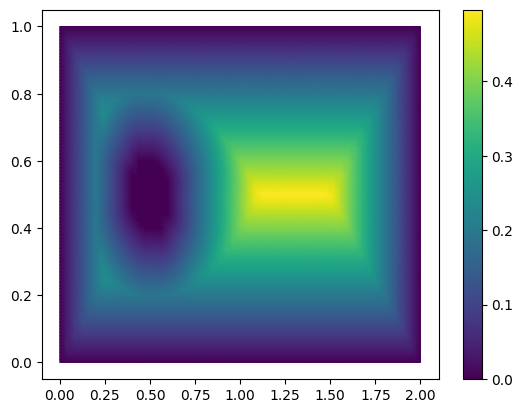

In [18]:
cm = firedrake.tripcolor(u)
plt.colorbar(cm)

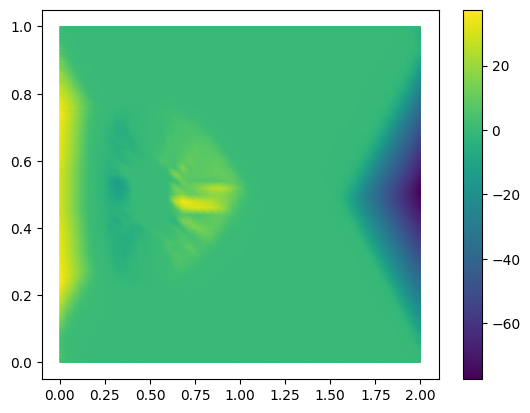

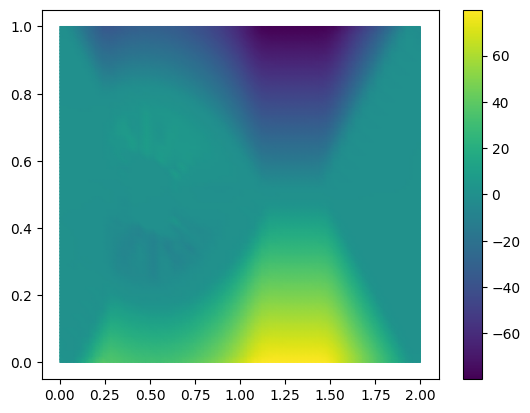

In [19]:
cm = firedrake.tripcolor(Function(V).interpolate(psi[0]))
plt.colorbar(cm)
cm = firedrake.tripcolor(Function(V).interpolate(psi[1]))
plt.colorbar(cm)

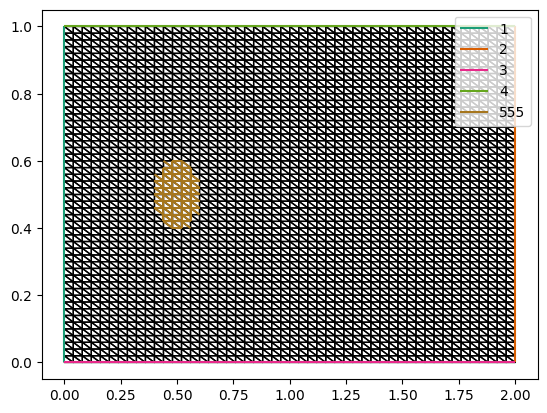

In [20]:
triplot(mesh)
plt.legend()